In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
# Set style
sns.set(style="whitegrid")
from sklearn.preprocessing import LabelEncoder




In [45]:
# Load the Excel file
df = pd.read_excel("/content/SHEET.xlsx")

# Display the first few rows
print("Head of Dataset:")
df.head()

Head of Dataset:


,Name,Age,Gender,DM,HTN,IHD,Family History,Weight,height,EAT from PLAX at end diastole,EAT from PASX at end diastole,LVEDd,IVSd,PWd,EF %,LVM,LVMI,E/'e
0,جمعه عبد الغني,51.0,M,no,yes,no,no,80.0,170.0,6.0,5.0,48.0,12.0,13.0,58.0,232.0,119.5,8.0
1,بيومي كاما,56.0,M,no,yes,no,no,85.0,170.0,6.0,6.0,52.0,12.0,12.0,60.0,248.0,124.0,10.0
2,جمال احمد,52.0,M,no,yes,no,no,75.0,165.0,5.0,4.0,45.0,12.0,13.0,57.0,210.0,113.0,10.0
3,سعيد بكر,48.0,M,no,yes,no,HTN,70.0,170.0,7.0,7.0,50.0,13.0,13.0,58.0,261.8,138.0,8.0
4,سمير احمد,57.0,M,no,yes,no,no,85.0,170.0,8.0,7.0,55.0,13.0,12.0,65.0,288.0,143.8,10.0


In [46]:

# Basic info
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Name                           136 non-null    object 
 1   Age                            135 non-null    float64
 2   Gender                         135 non-null    object 
 3   DM                             135 non-null    object 
 4   HTN                            135 non-null    object 
 5   IHD                            135 non-null    object 
 6   Family History                 135 non-null    object 
 7   Weight                         135 non-null    float64
 8   height                         135 non-null    float64
 9   EAT from PLAX at end diastole  135 non-null    float64
 10  EAT from PASX at end diastole  135 non-null    float64
 11  LVEDd                          135 non-null    float64
 12  IVSd                           135 

In [47]:
# Drop the 'Name' column if it exists
if 'Name' in df.columns:
    df.drop(columns=['Name'], inplace=True)
    print("Dropped 'Name' column.")


Dropped 'Name' column.


In [48]:

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Age                              1
Gender                           1
DM                               1
HTN                              1
IHD                              1
Family History                   1
Weight                           1
height                           1
EAT from PLAX at end diastole    1
EAT from PASX at end diastole    1
LVEDd                            1
IVSd                             1
PWd                              1
EF %                             1
LVM                              1
LVMI                             1
E/'e                             1
dtype: int64


In [49]:

# Drop rows that have any null values
df.dropna(inplace=True)
# Check if any null values exist in the DataFrame
has_nulls = df.isnull().values.any()

if has_nulls:
    print("There are null values in the dataset.")
else:
    print("There are no null values in the dataset.")


There are no null values in the dataset.


In [50]:
# List of categorical columns
cat_cols = ['Gender', 'DM', 'HTN', 'IHD', 'Family History']

# Print number of unique values in each categorical column
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} unique categories: {df[col].unique()}")

Gender has 4 unique categories: ['M' 'F' 'f' 'm']
DM has 3 unique categories: ['no' 'yes' 'YES']
HTN has 2 unique categories: ['yes' 'no']
IHD has 1 unique categories: ['no']
Family History has 6 unique categories: ['no' 'HTN' 'DM' 'HTN,IHD' 'DM,IHD' 'HTN.DM']


In [51]:
# Standardize Gender column to lowercase
df['Gender'] = df['Gender'].str.lower()
df['Gender'] = df['Gender'].replace({'m': 'male', 'f': 'female'})

# Standardize DM column to lowercase
df['DM'] = df['DM'].str.lower()
df['DM'] = df['DM'].replace({'yes': 'yes', 'no': 'no'})  # Optional cleanup, ensures consistency

# Check results
print(df['Gender'].unique())
print(df['DM'].unique())


['male' 'female']
['no' 'yes']


In [52]:
#drop low variance col.
df.drop(columns=['IHD'], inplace=True)

In [53]:
# Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

# Remove duplicates
df = df.drop_duplicates()
print("Duplicate rows removed.")


Number of duplicate rows: 0
Duplicate rows removed.


In [54]:
# Summary statistics for numeric columns
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,Age,Weight,height,EAT from PLAX at end diastole,EAT from PASX at end diastole,LVEDd,IVSd,PWd,EF %,LVM,LVMI,E/'e
count,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000
mean,54.503704,83.881481,169.940741,6.074074,5.407407,48.392593,11.725926,11.814815,61.770370,222.320000,110.312593,9.162963
std,3.945286,5.080034,5.465991,1.677906,1.487742,3.917234,1.809715,1.779591,4.460341,64.405411,27.470077,1.738319
min,45.000000,70.000000,160.000000,3.000000,3.000000,40.000000,7.000000,7.000000,57.000000,93.000000,47.000000,6.000000
25%,51.000000,80.000000,165.000000,5.000000,4.000000,45.000000,11.000000,11.000000,58.000000,176.800000,91.750000,8.000000
50%,54.000000,85.000000,170.000000,6.000000,5.000000,48.000000,12.000000,12.000000,61.000000,219.000000,113.000000,9.000000
75%,57.000000,85.000000,175.000000,8.000000,7.000000,51.000000,13.000000,13.000000,64.000000,258.800000,126.000000,10.000000
max,63.000000,95.000000,180.000000,10.000000,8.000000,56.000000,16.000000,16.000000,77.000000,555.500000,191.000000,12.000000


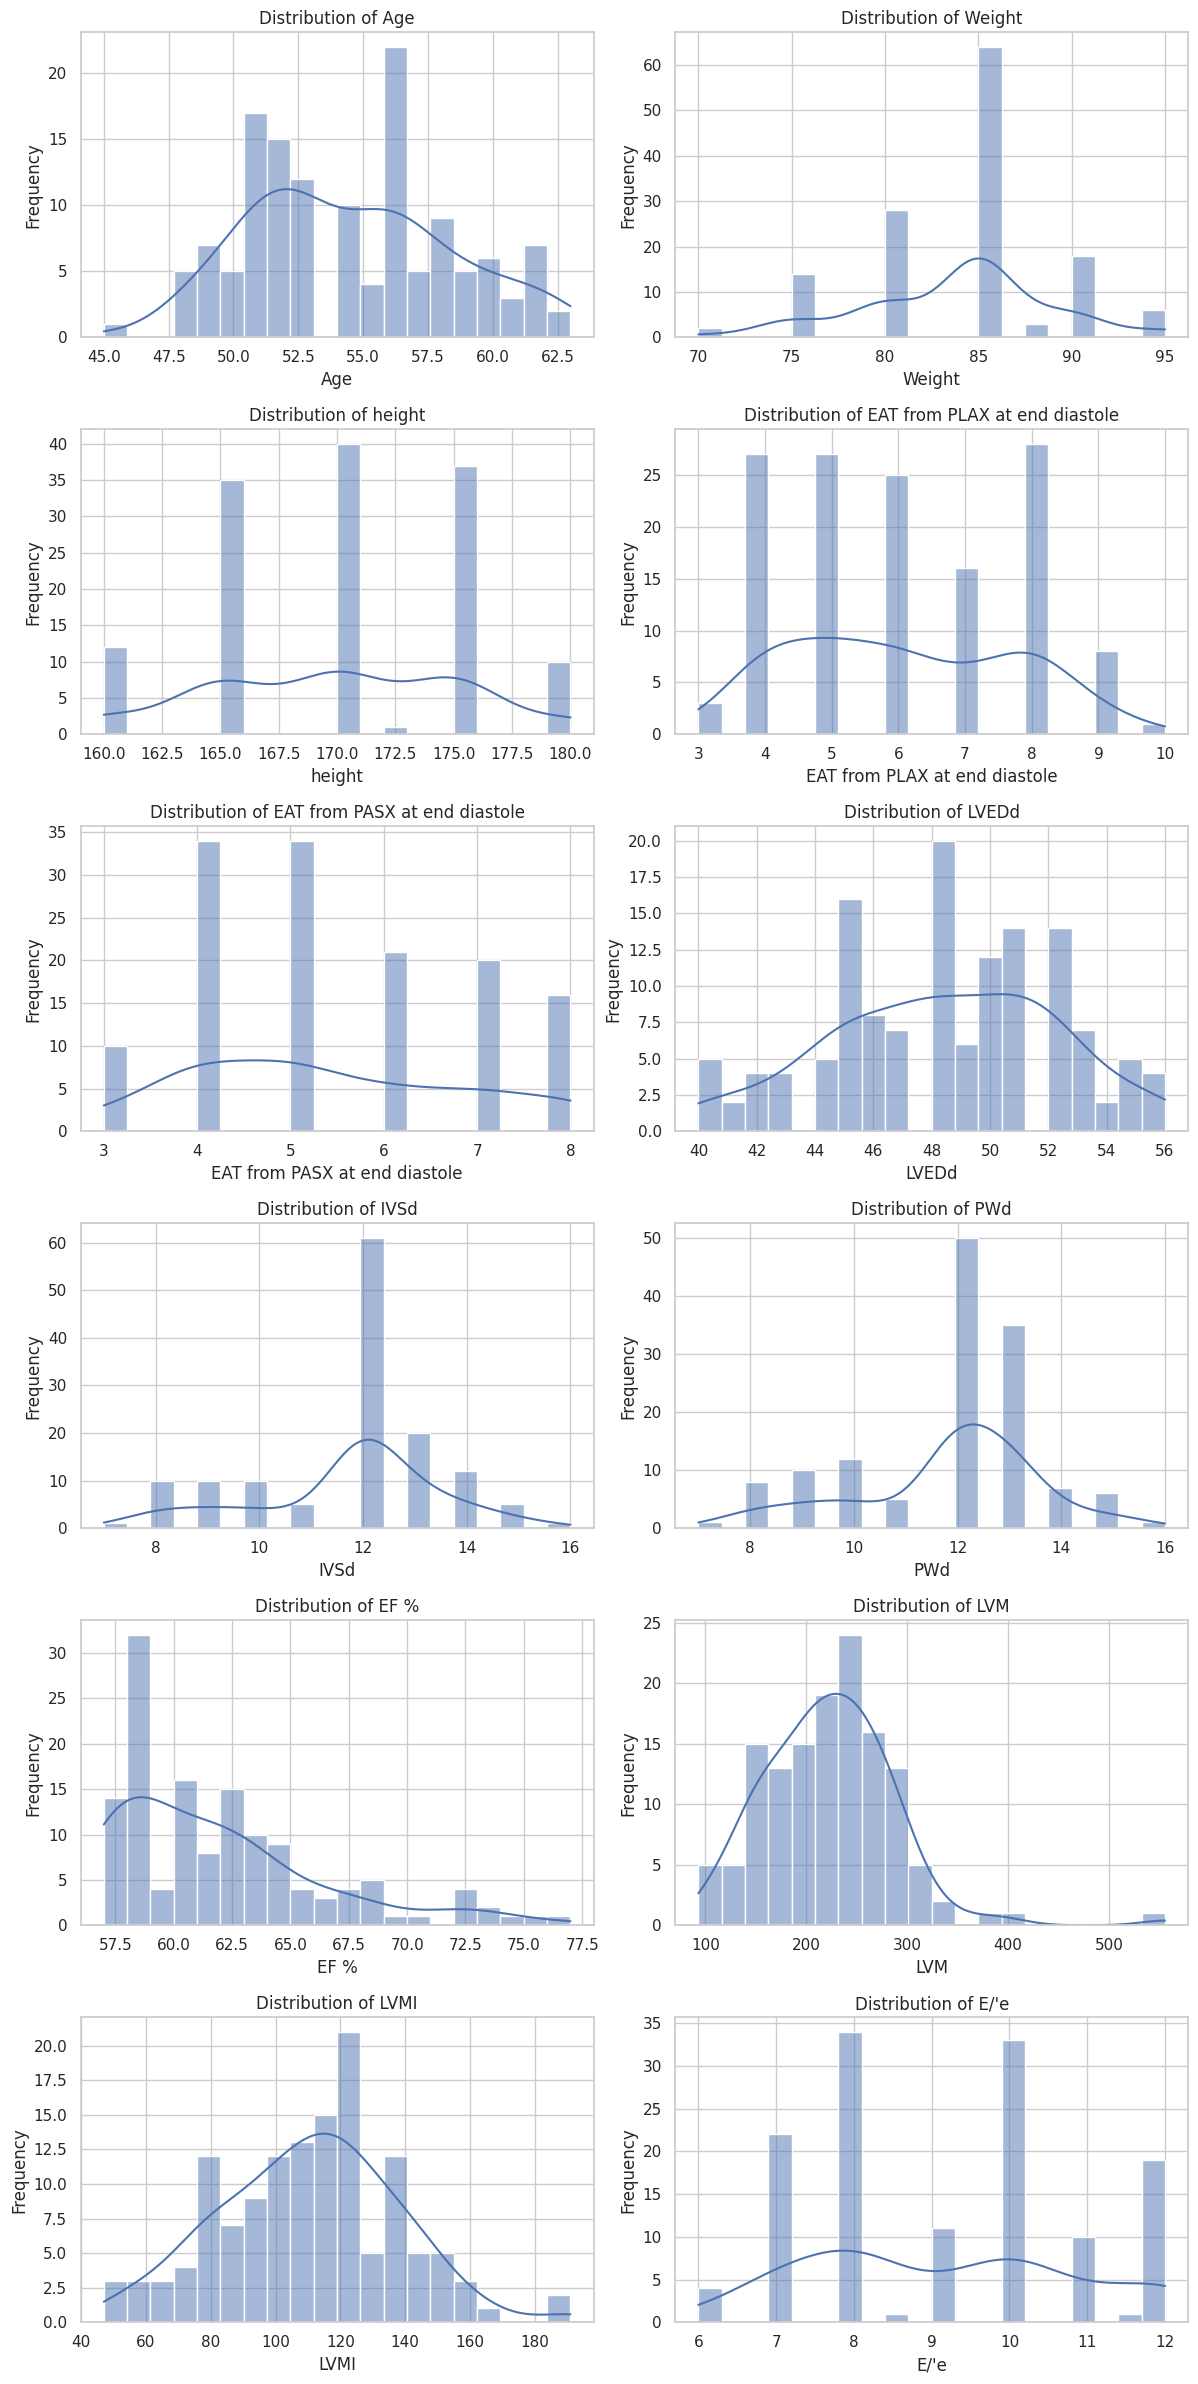

In [55]:
# -----------------------------
# Visualizations
# -----------------------------

# Histogram for numeric features
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = len(numeric_cols)
num_rows = (num_cols + 1) // 2  # Calculate rows, rounding up
fig, axes = plt.subplots(num_rows, 2, figsize=(12, num_rows * 4))  # Adjust figsize as needed
for i, col in enumerate(numeric_cols):
       row = i // 2  # Calculate subplot row index
       col_index = i % 2  # Calculate subplot column index
       ax = axes[row, col_index]  # Get the current subplot

       sns.histplot(df[col], kde=True, bins=20, ax=ax)
       ax.set_title(f"Distribution of {col}")
       ax.set_xlabel(col)
       ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

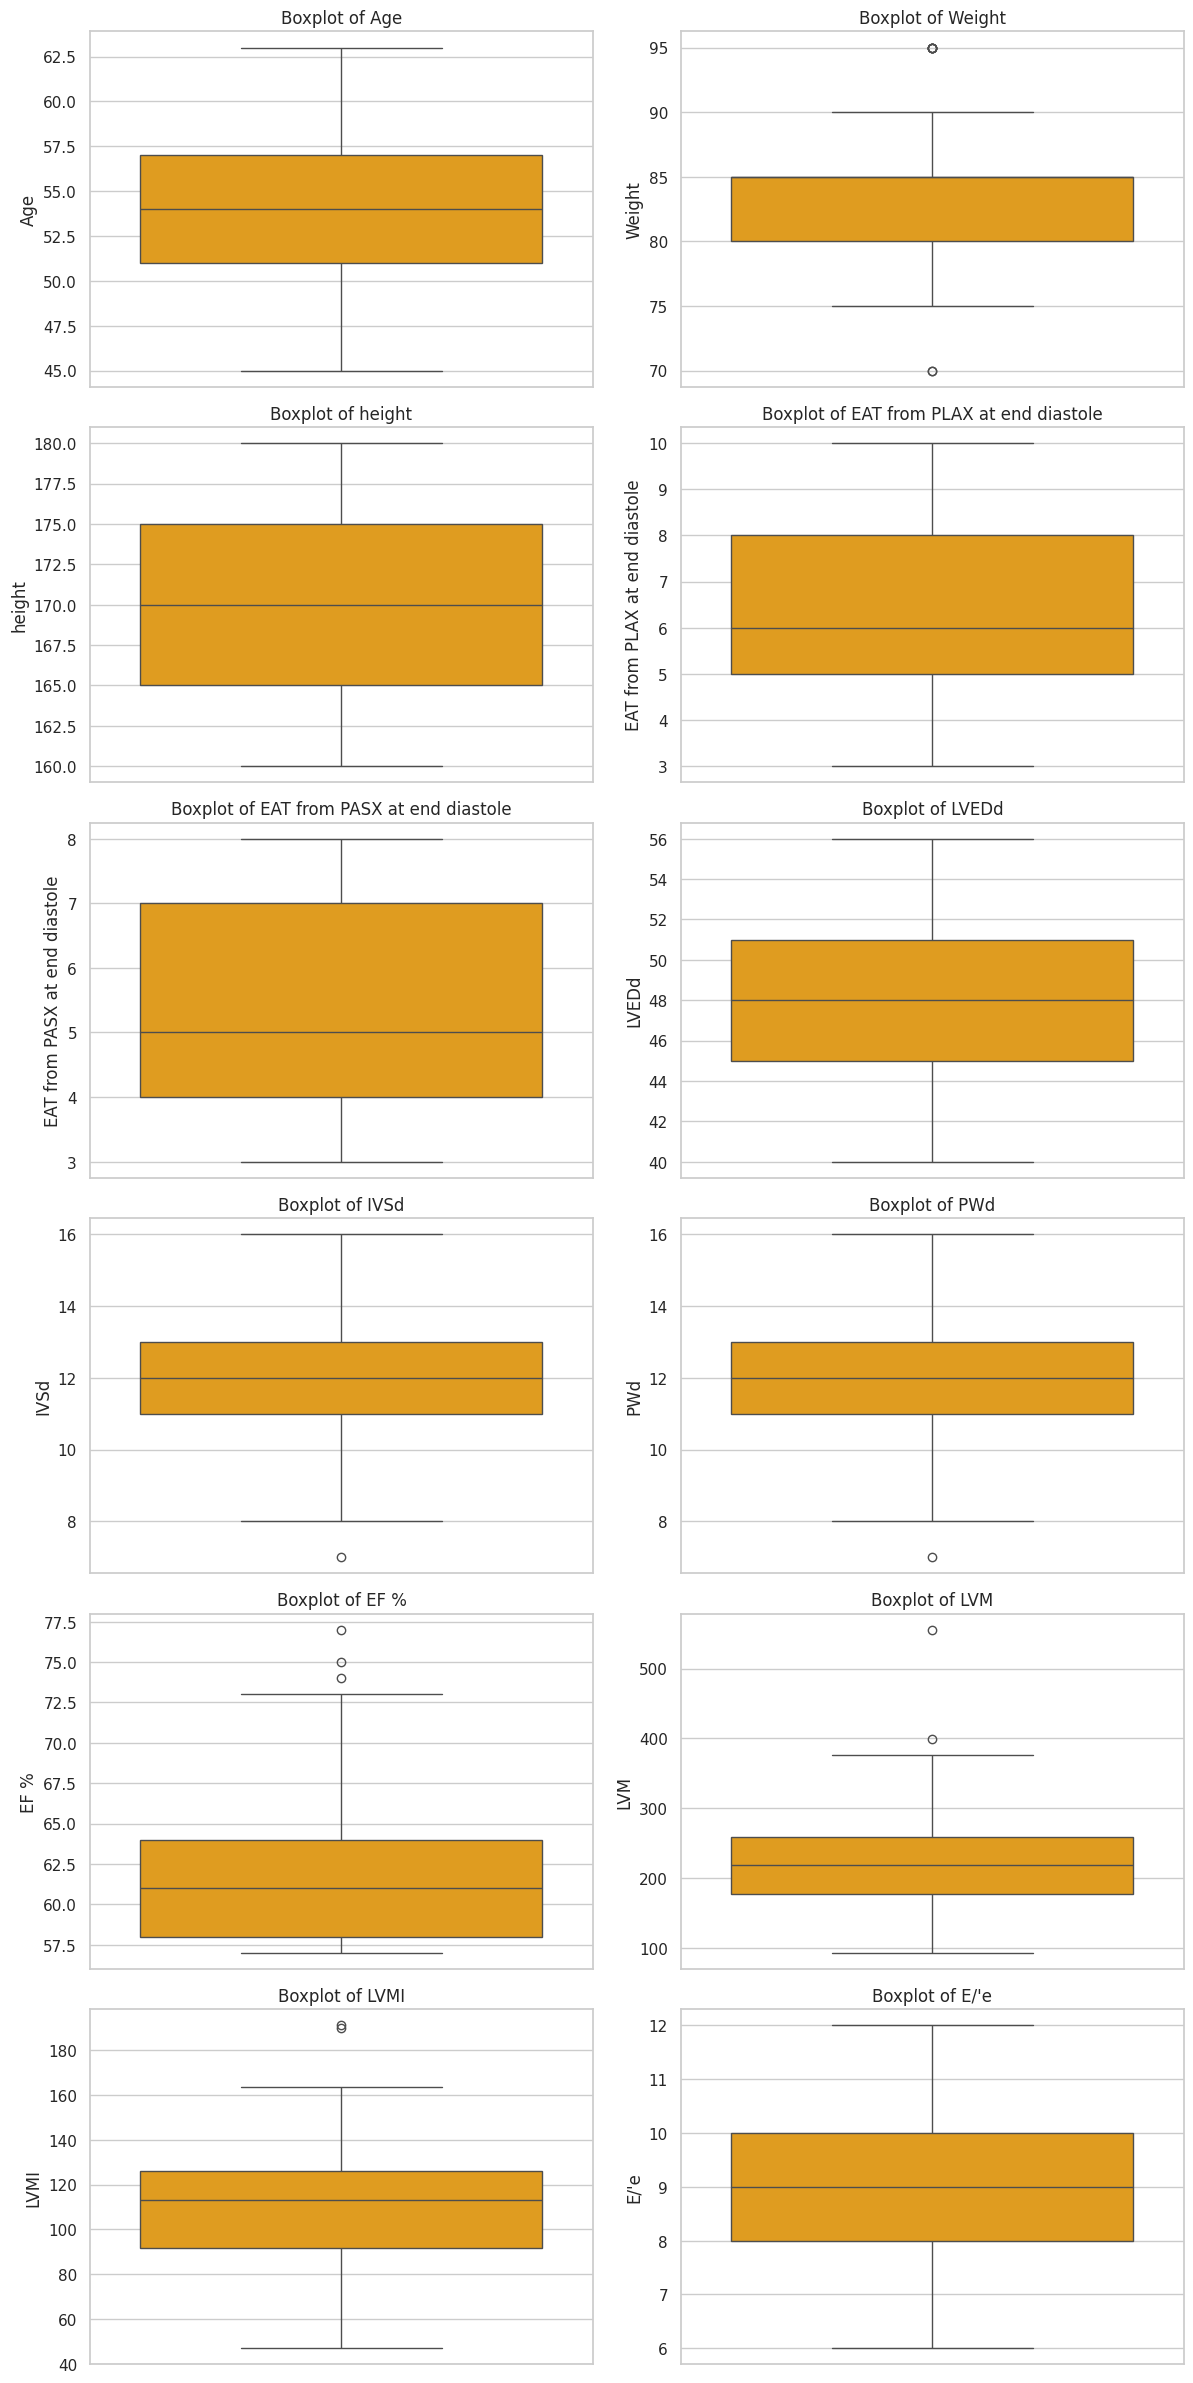

In [56]:

# Boxplots to check outliers

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = len(numeric_cols)
num_rows = (num_cols + 1) // 2  # Calculate rows, rounding up

fig, axes = plt.subplots(num_rows, 2, figsize=(12, num_rows * 4))  # Adjust figsize as needed

for i, col in enumerate(numeric_cols):
    row = i // 2  # Calculate subplot row index
    col_index = i % 2  # Calculate subplot column index
    ax = axes[row, col_index]  # Get the current subplot

    sns.boxplot(data=df, y=col, ax=ax, color='orange')  # Change color here
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)  # Set y-axis label

plt.tight_layout()
plt.show()


In [57]:
import pandas as pd

def detect_outlier_columns(df, threshold=1.5):
    """
    Detects columns in a DataFrame that contain outliers using the IQR method.

    Args:
        df (pd.DataFrame): The input DataFrame.
        threshold (float, optional): The IQR multiplier for outlier detection.
                                     Defaults to 1.5.

    Returns:
        list: A list of column names containing outliers.
    """

    outlier_cols = []
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        if df[(df[col] < lower_bound) | (df[col] > upper_bound)].any(axis=None):
            outlier_cols.append(col)

    return outlier_cols

In [58]:
outlier_columns = detect_outlier_columns(df)

# Print the columns with outliers
print("Columns with outliers:", outlier_columns)

Columns with outliers: ['Weight', 'IVSd', 'PWd', 'EF %', 'LVM', 'LVMI']


In [59]:
import pandas as pd

# ... (detect_outlier_columns function from previous response) ...

def handle_outliers_iqr(df, threshold=1.5):
    """
    Handles outliers in a DataFrame using the IQR method with capping.

    Args:
        df (pd.DataFrame): The input DataFrame.
        threshold (float, optional): The IQR multiplier for outlier detection.
                                     Defaults to 1.5.

    Returns:
        pd.DataFrame: The DataFrame with outliers handled.
    """

    outlier_cols = detect_outlier_columns(df, threshold)

    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Capping outliers:
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

In [60]:
# Assuming you have your DataFrame 'df'
df_handled = handle_outliers_iqr(df)


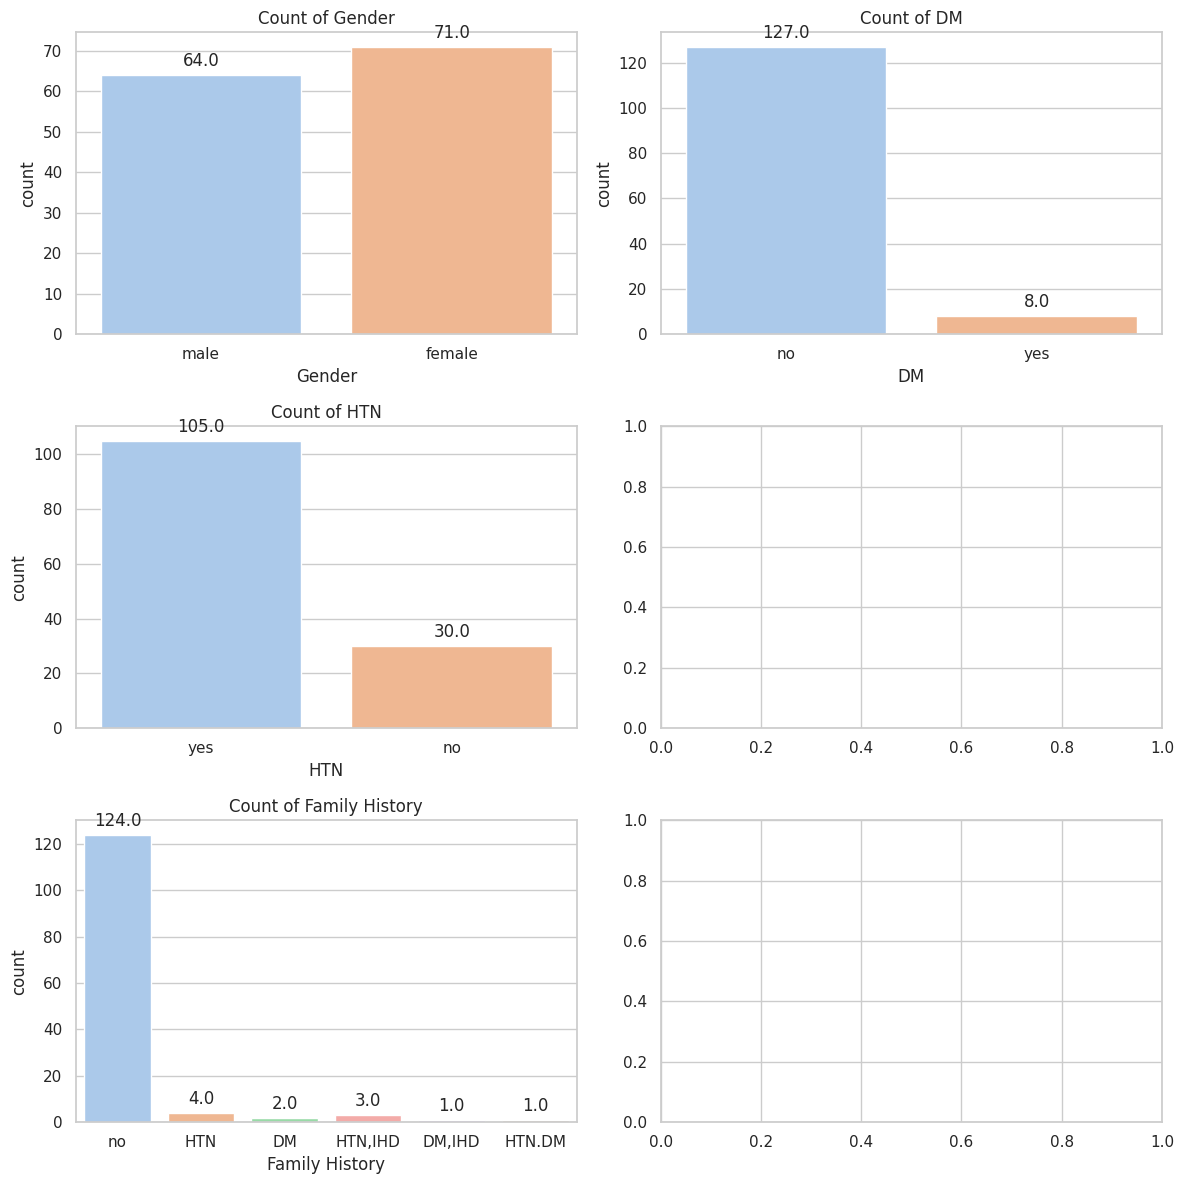

In [61]:

# Count plots for categorical variables
# Count plots with subplots and annotations
# Count plots with subplots, annotations, and color palettes
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Gender', 'DM', 'HTN', 'IHD', 'Family History']
num_cols = len(categorical_cols)
num_rows = (num_cols + 1) // 2  # Calculate rows, rounding up

fig, axes = plt.subplots(num_rows, 2, figsize=(12, num_rows * 4))  # Adjust figsize as needed

for i, col in enumerate(categorical_cols):
    if col in df_handled.columns:
        row = i // 2  # Calculate subplot row index
        col_index = i % 2  # Calculate subplot column index
        ax = axes[row, col_index]  # Get the current subplot

        # Use a color palette for the count plot
        num_categories = len(df_handled[col].unique())  # Number of categories in the column
        palette = sns.color_palette("pastel", num_categories)  # Choose a palette with enough colors

        sns.countplot(data=df_handled, x=col, ax=ax, palette=palette)
        ax.set_title(f"Count of {col}")

        # Annotate the bars with values
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

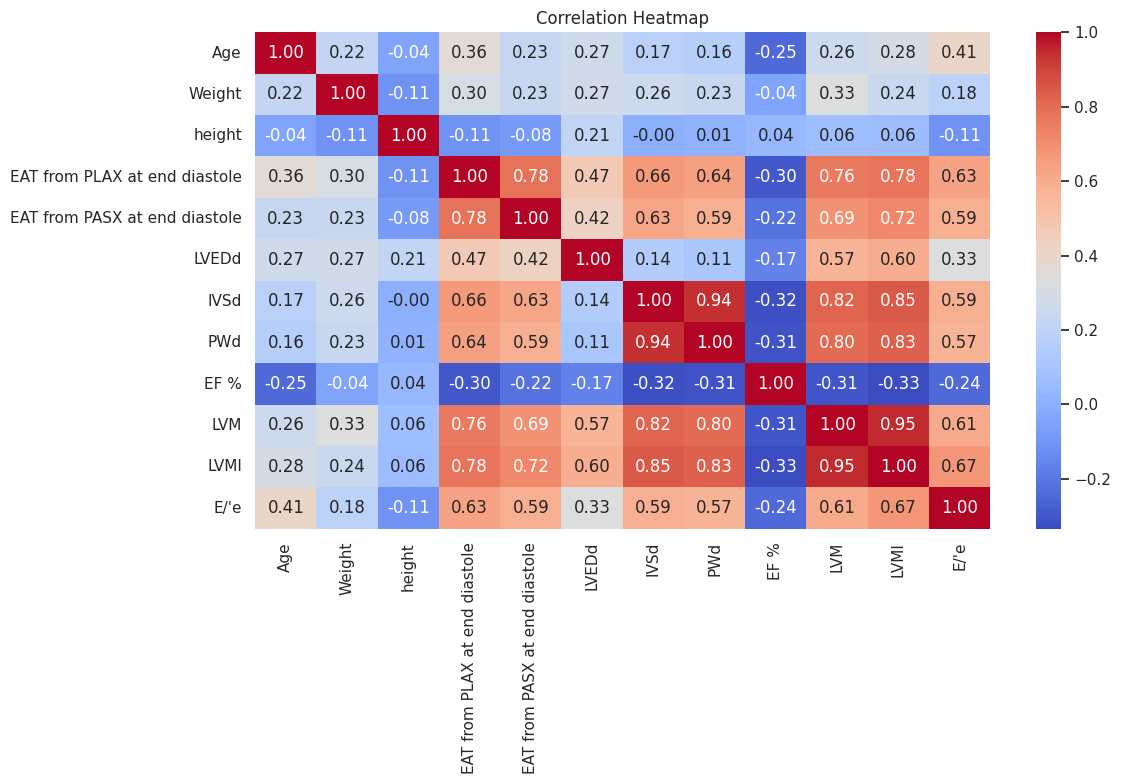

In [62]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_handled[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [63]:
df_handled.head(

)

,Age,Gender,DM,HTN,Family History,Weight,height,EAT from PLAX at end diastole,EAT from PASX at end diastole,LVEDd,IVSd,PWd,EF %,LVM,LVMI,E/'e
0,51.0,male,no,yes,no,80.0,170.0,6.0,5.0,48.0,12.0,13.0,58.0,232.0,119.5,8.0
1,56.0,male,no,yes,no,85.0,170.0,6.0,6.0,52.0,12.0,12.0,60.0,248.0,124.0,10.0
2,52.0,male,no,yes,no,75.0,165.0,5.0,4.0,45.0,12.0,13.0,57.0,210.0,113.0,10.0
3,48.0,male,no,yes,HTN,72.5,170.0,7.0,7.0,50.0,13.0,13.0,58.0,261.8,138.0,8.0
4,57.0,male,no,yes,no,85.0,170.0,8.0,7.0,55.0,13.0,12.0,65.0,288.0,143.8,10.0


In [66]:

# Separate binary and non-binary categorical columns
# Remove 'IHD' from cat_cols since it's no longer in the DataFrame
cat_cols = [col for col in cat_cols if col in df_handled.columns]

binary_cols = [col for col in cat_cols if df_handled[col].nunique() == 2]
multi_cols = [col for col in cat_cols if df_handled[col].nunique() > 2]

# Apply Label Encoding for binary columns
le = LabelEncoder()
for col in binary_cols:
    df_handled[col] = le.fit_transform(df_handled[col])

# Apply One-Hot Encoding for non-binary columns
df_encoded = pd.get_dummies(df_handled, columns=multi_cols, drop_first=True)

# Now df is ready for modeling
print("\nData after encoding:")
df_encoded.head()


Data after encoding:


,Age,Gender,DM,HTN,Weight,height,EAT from PLAX at end diastole,EAT from PASX at end diastole,LVEDd,IVSd,PWd,EF %,LVM,LVMI,E/'e,"Family History_DM,IHD",Family History_HTN,"Family History_HTN,IHD",Family History_HTN.DM,Family History_no
0,51.0,1,0,1,80.0,170.0,6.0,5.0,48.0,12.0,13.0,58.0,232.0,119.5,8.0,False,False,False,False,True
1,56.0,1,0,1,85.0,170.0,6.0,6.0,52.0,12.0,12.0,60.0,248.0,124.0,10.0,False,False,False,False,True
2,52.0,1,0,1,75.0,165.0,5.0,4.0,45.0,12.0,13.0,57.0,210.0,113.0,10.0,False,False,False,False,True
3,48.0,1,0,1,72.5,170.0,7.0,7.0,50.0,13.0,13.0,58.0,261.8,138.0,8.0,False,True,False,False,False
4,57.0,1,0,1,85.0,170.0,8.0,7.0,55.0,13.0,12.0,65.0,288.0,143.8,10.0,False,False,False,False,True


In [70]:
# Split features and target
X = df_encoded.drop(columns=["LVMI"])
y = df_encoded["LVMI"]

# Use RandomForestRegressor for continuous target
from sklearn.ensemble import RandomForestRegressor  # Import the regressor
from sklearn.feature_selection import f_regression # Import f_regression
model = RandomForestRegressor(random_state=42)  # Change to Regressor
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features_rf = importances.sort_values(ascending=False)

# Feature selection using ANOVA F-test (may need adjustment for regression)
selector = SelectKBest(score_func=f_regression, k="all") # Use f_regression for continuous target
selector.fit(X, y)
scores = pd.Series(selector.scores_, index=X.columns)
top_features_anova = scores.sort_values(ascending=False)

# Combine and display
print("Top features by Random Forest:\n", top_features_rf.head(10))
print("\nTop features by ANOVA F-test:\n", top_features_anova.head(10))

Top features by Random Forest:
 LVM                              0.902789
PWd                              0.024881
IVSd                             0.022695
E/'e                             0.014095
LVEDd                            0.010268
EAT from PASX at end diastole    0.004546
Weight                           0.004505
EF %                             0.003866
Age                              0.003848
Family History_HTN               0.003243
dtype: float64

Top features by ANOVA F-test:
 LVM                              1265.462512
IVSd                              342.692763
PWd                               296.712322
EAT from PLAX at end diastole     201.313558
EAT from PASX at end diastole     142.859805
E/'e                              110.383328
HTN                               105.683440
LVEDd                              73.161070
EF %                               16.773996
Age                                11.521143
dtype: float64


Feature Weights:
 LVM                              6.281949
IVSd                             7.319618
PWd                              8.678727
EAT from PLAX at end diastole   -0.265575
EAT from PASX at end diastole    0.645322
E/'e                             1.640901
HTN                             -0.597733
LVEDd                            9.195586
EF %                            -0.332692
Age                              0.039636
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                   LVMI   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     471.0
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.52e-93
Time:                        22:48:44   Log-Likelihood:                -388.43
No. Observations:                 135   AIC:                             

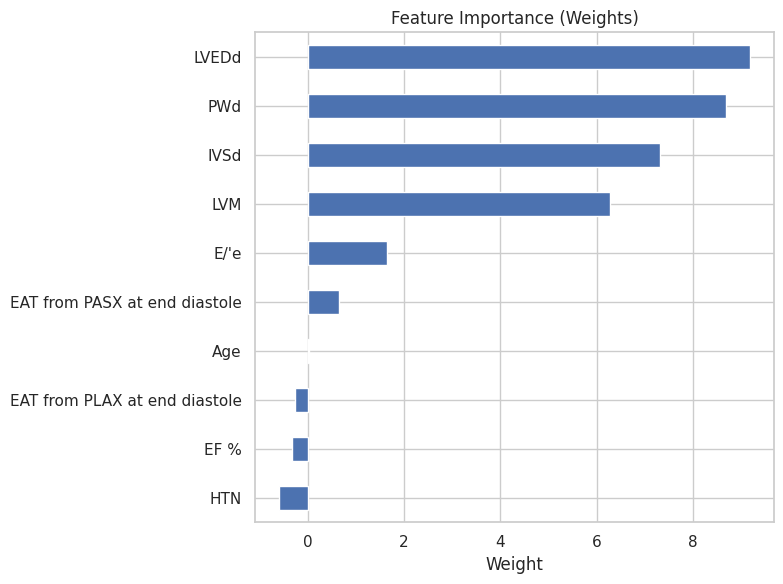

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt


# Selected features and target
features = ['LVM', 'IVSd', 'PWd', 'EAT from PLAX at end diastole',
            'EAT from PASX at end diastole', "E/'e", 'HTN', 'LVEDd', 'EF %', 'Age']
target = 'LVMI'

X = df_encoded[features]
y = df_encoded[target]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42)

# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Feature weights (coefficients)
feature_weights = pd.Series(model.coef_, index=features)
print("Feature Weights:\n", feature_weights)

# Statsmodels for p-values
X_const = sm.add_constant(X_scaled)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

# Plot feature importance
feature_weights.sort_values().plot(kind='barh', figsize=(8, 6), title="Feature Importance (Weights)")
plt.xlabel("Weight")
plt.tight_layout()
plt.show()


Your regression model shows very strong results with an R-squared of 0.974, indicating that your selected features explain a large proportion of the variance in LVMI.

Key Insights:
Statistically significant predictors (p-value < 0.05):

LVM, IVSd, PWd, E/'e, LVEDd — these have a strong effect on LVMI.

Non-significant features:

EAT from PLAX, EAT from PASX, HTN, EF %, Age — these have p > 0.05, so their effect is not statistically significant in this model.

R2 Score: 0.9381138411928323
MSE: 41.65911486275119
                            OLS Regression Results                            
Dep. Variable:                   LVMI   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     709.1
Date:                Thu, 01 May 2025   Prob (F-statistic):           1.25e-95
Time:                        22:27:17   Log-Likelihood:                -397.19
No. Observations:                 135   AIC:                             808.4
Df Residuals:                     128   BIC:                             828.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

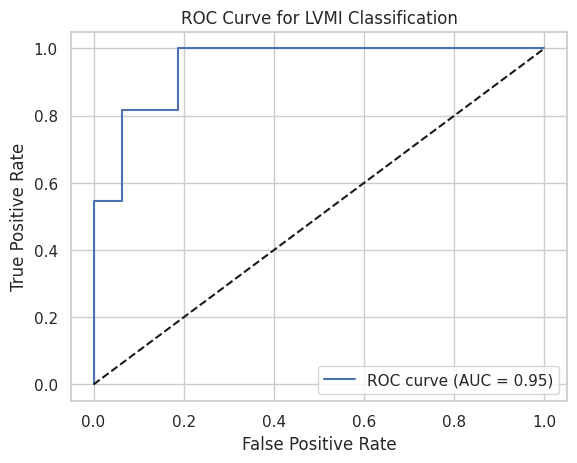

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm



# Define features and target
X = df_encoded[['EAT from PLAX at end diastole', 'EAT from PASX at end diastole', 'LVEDd', 'IVSd', 'PWd', "E/'e"]]
y = df['LVMI']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print('R2 Score:', r2_score(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

# Significance (p-values) using statsmodels
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

# Convert LVMI to binary for ROC analysis (example: threshold = 115)
threshold = 115
y_binary = (y > threshold).astype(int)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Logistic Regression for ROC
clf = LogisticRegression()
clf.fit(X_train_bin, y_train_bin)
y_probs = clf.predict_proba(X_test_bin)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_bin, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LVMI Classification')
plt.legend(loc="lower right")
plt.show()


✅ Regression Results Summary
R² Score: 0.971 – This means 97.1% of the variation in LVMI is explained by your selected predictors.

MSE: 41.66 – The average squared error; relatively low, indicating good fit.

Significant Predictors (p < 0.05):

LVEDd, IVSd, PWd, E/'e – These strongly affect LVMI.

Non-significant Predictors:

EAT from PLAX and EAT from PASX (p > 0.05) – EAT shows minimal independent impact on LVMI in this regression.

✅ Classification Results (using ROC)
AUC = 0.95 – Excellent classifier performance in distinguishing between high and low LVMI categories.



Optimal EAT threshold (PLAX): 6.0
AUC: 0.9034810126582279


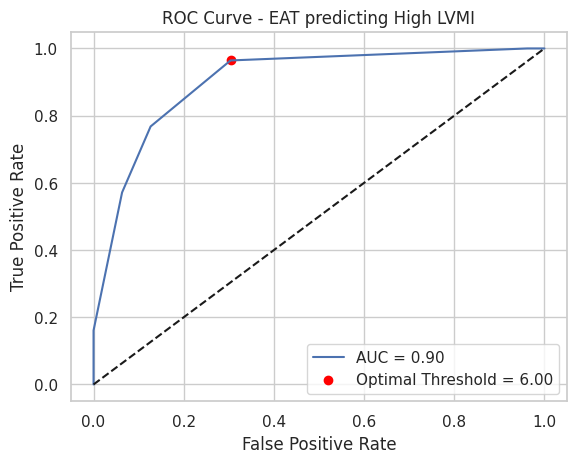

In [73]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 1: Binarize LVMI based on threshold (e.g., >115 is high)
df_encoded['LVMI_High'] = (df_encoded['LVMI'] > 115).astype(int)

# Step 2: Choose EAT feature (e.g., PLAX)
eat_values = df_encoded["EAT from PLAX at end diastole"]
lvmi_labels = df_encoded["LVMI_High"]

# Step 3: Compute ROC curve
fpr, tpr, thresholds = roc_curve(lvmi_labels, eat_values)

# Step 4: Calculate Youden's J statistic to find optimal threshold
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
print("Optimal EAT threshold (PLAX):", optimal_threshold)

# Optional: AUC score
auc_score = roc_auc_score(lvmi_labels, eat_values)
print("AUC:", auc_score)

# Optional: Plot ROC Curve
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - EAT predicting High LVMI")
plt.legend()
plt.grid(True)
plt.show()


In [83]:
# Example new patient data as dictionary
new_data = {
     'LVM': 60,  # Example value, replace with actual
    'IVSd': 12,  # Example value, replace with actual
    'PWd': 10,  # Example value, replace with actual
    'EAT from PLAX at end diastole': 5.2,
    'EAT from PASX at end diastole': 4.8,
    "E/'e": 13,
    'HTN': 1,  # Assuming HTN was encoded to 1/0, replace with actual encoding
    'LVEDd': 50,
    'EF %': 55,  # Example value, replace with actual
    'Age': 65
}

# Convert to DataFrame
new_df = pd.DataFrame([new_data])

# Apply the same scaler used in training
new_scaled = scaler.transform(new_df)

# Predict using the *trained* model
predicted_lvmi = model.predict(new_scaled)  # Use the trained 'model'
print("Predicted LVMI:", predicted_lvmi[0])


Predicted LVMI: 92.44262989988223
